In [1]:
import torch

# Check if CUDA (GPU support) is available
gpu_available = torch.cuda.is_available()
print(f"Is GPU available? {gpu_available}")

if gpu_available:
    device_name = torch.cuda.get_device_name(0)
    print(f"Connected GPU: {device_name}")

    print(f"Active CUDA Device index: {torch.cuda.current_device()}")
    print(f"Device capability: {torch.cuda.get_device_capability(0)}")
else:
    print("No GPU detected. Please go to Runtime -> Change runtime type and select 'T4 GPU'.")


Is GPU available? True
Connected GPU: Tesla T4
Active CUDA Device index: 0
Device capability: (7, 5)


In [2]:
!pip install -q tensorflow pandas numpy matplotlib seaborn pillow opencv-python scikit-learn


In [3]:
import os
import json
import random
import shutil
import zipfile
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import cv2

import tensorflow as tf

from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print(
    "Available GPUs:",
    tf.config.list_physical_devices("GPU")
)


TensorFlow version: 2.21.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

print("Random seed:", SEED)


Random seed: 42


In [8]:
PROJECT_ROOT = Path.cwd()

GRADCAM_DIR = PROJECT_ROOT / "gradcam_results"

MODEL_DIR =  GRADCAM_DIR / "models"
GRADCAM_IMAGES_DIR = GRADCAM_DIR / "images"
GRADCAM_HEATMAP_DIR = GRADCAM_DIR / "heatmaps"
GRADCAM_OVERLAY_DIR = GRADCAM_DIR / "overlays"
GRADCAM_VISUALIZATION_DIR = GRADCAM_DIR / "visualizations"
GRADCAM_REPORT_DIR = GRADCAM_DIR / "reports"
GRADCAM_METADATA_DIR = GRADCAM_DIR / "metadata"
GRADCAM_PREDICTION_DIR = GRADCAM_DIR / "predictions"

for directory in [

    MODEL_DIR,
    GRADCAM_DIR,
    GRADCAM_IMAGES_DIR,
    GRADCAM_HEATMAP_DIR,
    GRADCAM_OVERLAY_DIR,
    GRADCAM_VISUALIZATION_DIR,
    GRADCAM_REPORT_DIR,
    GRADCAM_METADATA_DIR,
    GRADCAM_PREDICTION_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Grad-CAM output directory:")
print(GRADCAM_DIR)


Grad-CAM output directory:
/content/gradcam_results


In [6]:
IMAGE_SIZE = (224, 224)

CLASS_NAMES = [
    "COVID-19",
    "Non-COVID Infection",
    "Normal"
]

CLASS_TO_INDEX = {
    "COVID-19": 0,
    "Non-COVID Infection": 1,
    "Normal": 2
}

INDEX_TO_CLASS = {
    0: "COVID-19",
    1: "Non-COVID Infection",
    2: "Normal"
}

MODEL_NAME = "DenseNet121"

NORMALIZATION = "1/255"

ALPHA = 0.40

HEATMAP_COLORMAP = cv2.COLORMAP_JET

print("Model:", MODEL_NAME)
print("Image size:", IMAGE_SIZE)
print("Classes:", CLASS_NAMES)



Model: DenseNet121
Image size: (224, 224)
Classes: ['COVID-19', 'Non-COVID Infection', 'Normal']


In [10]:
possible_model_paths = [

    MODEL_DIR / "best_densenet121_covidqu.keras",

    PROJECT_ROOT
    / "best_densenet121_covidqu.keras",

    PROJECT_ROOT
    / "model.keras"

]

MODEL_PATH = None

for candidate in possible_model_paths:

    if candidate.exists():

        MODEL_PATH = candidate

        break


if MODEL_PATH is None:

    raise FileNotFoundError(
        """
        Could not find the trained .keras model.

        Please update MODEL_PATH manually in CELL 6.
        """
    )


print("Model found:")
print(MODEL_PATH)


Model found:
/content/gradcam_results/models/best_densenet121_covidqu.keras


In [12]:
model = load_model(
    MODEL_PATH
)

print(
    "DenseNet121 model successfully loaded."
)

print(
    "\nModel input shape:"
)

print(
    model.input_shape
)

print(
    "\nModel output shape:"
)

print(
    model.output_shape
)


DenseNet121 model successfully loaded.

Model input shape:
(None, 224, 224, 3)

Model output shape:
(None, 3)


In [13]:
if model.output_shape[-1] != len(CLASS_NAMES):

    raise ValueError(
        "Model output classes do not match CLASS_NAMES."
    )

print(
    "Model has",
    model.output_shape[-1],
    "output classes."
)

print(
    "Expected classes:",
    CLASS_NAMES
)


Model has 3 output classes.
Expected classes: ['COVID-19', 'Non-COVID Infection', 'Normal']


In [14]:
model.summary()


Model: "DenseNet121_COVIDQU_Ex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xray (InputLayer)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,362,891 (43.35 MB)

 Trainable params: 2,161,155 (8.24 MB)

 Non-trainable params: 4,879,424 (18.61 MB)

 Optimizer params: 4,322,312 (16.49 MB)

In [15]:
print(
    "\nMODEL LAYERS\n"
)

for index, layer in enumerate(model.layers):

    print(
        f"{index:03d} | "
        f"{layer.name:45s} | "
        f"{layer.__class__.__name__}"
    )



MODEL LAYERS

000 | xray                                          | InputLayer
001 | densenet121                                   | Functional
002 | global_average_pooling                        | GlobalAveragePooling2D
003 | dropout                                       | Dropout
004 | classifier                                    | Dense


In [24]:

conv_layer_candidates = []

for layer in model.layers:

    layer_name = layer.name.lower()

    layer_type = layer.__class__.__name__.lower()

    if (
        "conv" in layer_name
        or "conv" in layer_type
    ):

        conv_layer_candidates.append(
            layer.name
        )


print(
    "\nNumber of convolutional layer candidates:",
    len(conv_layer_candidates)
)

print(
    "\nLast 20 convolutional candidates:"
)

for layer_name in conv_layer_candidates[-20:]:

    print(layer_name)




Number of convolutional layer candidates: 0

Last 20 convolutional candidates:


In [23]:
if len(conv_layer_candidates) == 0:
    # Find the nested functional model (usually 'densenet121' at index 1)
    sub_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) or layer.__class__.__name__ == 'Functional':
            sub_model = layer
            break

    if sub_model is not None:
        print(f"Searching inside the nested sub-model: {sub_model.name}")
        for sub_layer in sub_model.layers:
            sub_layer_name = sub_layer.name.lower()
            sub_layer_type = sub_layer.__class__.__name__.lower()
            if "conv" in sub_layer_name or "conv" in sub_layer_type:
                conv_layer_candidates.append(f"{sub_model.name}/{sub_layer.name}")

if len(conv_layer_candidates) == 0:
    raise RuntimeError(
        "No convolutional layer was found even within the sub-model."
    )

# Select the last convolutional layer found
LAST_CONV_LAYER_NAME = conv_layer_candidates[-1]

print(
    "Automatically selected Grad-CAM layer:"
)
print(
    LAST_CONV_LAYER_NAME
)

Automatically selected Grad-CAM layer:
densenet121/conv5_block16_concat


In [25]:
if "/" in LAST_CONV_LAYER_NAME:
    sub_model_name, sub_layer_name = LAST_CONV_LAYER_NAME.split("/", 1)
    last_conv_layer = model.get_layer(sub_model_name).get_layer(sub_layer_name)
else:
    last_conv_layer = model.get_layer(LAST_CONV_LAYER_NAME)

print("Selected layer:")
print(last_conv_layer)
print("\nLayer output shape:")
print(last_conv_layer.output.shape)

Selected layer:
<Concatenate name=conv5_block16_concat, built=True>

Layer output shape:
(None, 7, 7, 1024)


In [26]:
grad_model = tf.keras.models.Model(

    inputs=model.inputs,

    outputs=[
        last_conv_layer.output,
        model.output
    ]

)

print(
    "Grad-CAM model created successfully."
)


Grad-CAM model created successfully.


In [31]:
import kagglehub
from pathlib import Path
import shutil

PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset"

print("Dataset directory:", DATASET_DIR)

kaggle_path = kagglehub.dataset_download(
    "anasmohammedtahir/covidqu"
)

print("Original KaggleHub dataset location:")
print(kaggle_path)

kaggle_path = Path(kaggle_path)

if DATASET_DIR.exists():
    for item in DATASET_DIR.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()

DATASET_DIR.mkdir(parents=True, exist_ok=True)

Dataset directory: /content/dataset


100%|██████████| 1.15G/1.15G [00:13<00:00, 91.5MB/s]

Extracting files...


Original KaggleHub dataset location:
/root/.cache/kagglehub/datasets/anasmohammedtahir/covidqu/versions/7


In [32]:
source_items = list(kaggle_path.iterdir()) if kaggle_path.is_dir() else []

if len(source_items) == 1 and source_items[0].is_dir():
    source_root = source_items[0]
else:
    source_root = kaggle_path

for item in source_root.iterdir():
    destination = DATASET_DIR / item.name
    if item.is_dir():
        shutil.copytree(item, destination)
    else:
        shutil.copy2(item, destination)

print("\nDataset copied to:")
print(DATASET_DIR.resolve())



Dataset copied to:
/content/dataset


In [33]:
for path in sorted(DATASET_DIR.rglob("*")):
    if path.is_dir():
        print(path.relative_to(DATASET_DIR))


DELETE_UNUSED_DATA = True

if DELETE_UNUSED_DATA:
    folders_to_delete = [
        DATASET_DIR / "Infection Segmentation Data",
    ]

    for folder in folders_to_delete:
        if folder.exists():
            print("Deleting unused folder:", folder)
            shutil.rmtree(folder)
        else:
            print("Folder not found; nothing to delete:", folder)
else:
    print("No downloaded dataset folders were deleted.")

print("Cleanup complete.")



Infection Segmentation Data
Infection Segmentation Data/Infection Segmentation Data
Infection Segmentation Data/Infection Segmentation Data/Test
Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19
Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19/images
Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19/infection masks
Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19/lung masks
Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID
Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID/images
Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID/infection masks
Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID/lung masks
Infection Segmentation Data/Infection Segmentation Data/Test/Normal
Infection Segmentation Data/Infection Segmentation Data/Test/Normal/images
Infection Segmentation Data/Infection Segmentation Data/Test/Normal/infection ma

In [34]:

def find_split_dir(root, split_name):
    matches = [
        p for p in root.rglob("*")
        if p.is_dir() and p.name.lower() == split_name.lower()
    ]
    if not matches:
        raise FileNotFoundError(f"Could not find {split_name} directory under {root}")
    # Prefer the deepest match that contains at least one expected class folder.
    expected_names = {"COVID-19", "Non-COVID", "Normal"}
    ranked = []
    for p in matches:
        child_names = {x.name for x in p.iterdir() if x.is_dir()}
        score = len(child_names & expected_names)
        ranked.append((score, len(p.parts), p))
    ranked.sort(reverse=True, key=lambda x: (x[0], x[1]))
    return ranked[0][2]


In [35]:
import shutil
from pathlib import Path

# Define the split directories we want to inspect
split_dirs = [
    Path('/content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train'),
    Path('/content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val'),
    Path('/content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test')
]

# Iterate through each split and delete any folder named 'lung masks'
for split in split_dirs:
    if split.exists():
        # Find all subdirectories within this split matching 'lung masks' (case-insensitive)
        for folder in split.rglob("*"):
            if folder.is_dir() and folder.name.lower() == "lung masks":
                print(f"Deleting folder: {folder}")
                shutil.rmtree(folder)
    else:
        print(f"Directory not found: {split}")

Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train/Non-COVID/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train/Normal/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train/COVID-19/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val/Non-COVID/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val/Normal/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val/COVID-19/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test/Non-COVID/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test/Normal/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/lung masks


In [37]:
import pandas as pd
from pathlib import Path

DATASET_DIR = PROJECT_ROOT / "dataset"

# Reconstruct test manifest dynamically from the downloaded dataset directory
test_images = []
test_base_dir = DATASET_DIR / "Lung Segmentation Data" / "Lung Segmentation Data" / "Test"

if test_base_dir.exists():
    for class_folder in ["COVID-19", "Non-COVID", "Normal"]:
        folder_path = test_base_dir / class_folder / "images"
        if folder_path.exists():
            for img_path in sorted(folder_path.glob("*")):
                if img_path.is_file():
                    test_images.append({
                        "sample_id": img_path.stem,
                        "class_name": "Non-COVID Infection" if class_folder == "Non-COVID" else class_folder,
                        "path": str(img_path.relative_to(PROJECT_ROOT))
                    })

test_df = pd.DataFrame(test_images)
print(f"Created test_df with {len(test_df)} samples dynamically.")

def resolve_image_path(path_value):
    path_value = Path(str(path_value))
    candidates = [
        path_value,
        PROJECT_ROOT / path_value,
        DATASET_DIR / path_value
    ]
    path_string = str(path_value)
    if path_string.startswith("dataset"):
        cleaned = path_string.split("dataset", 1)[-1].lstrip("/\\")
        candidates.append(DATASET_DIR / cleaned)

    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate.resolve()
    return None

test_df["resolved_path"] = test_df["path"].apply(resolve_image_path)

missing_paths = test_df["resolved_path"].isna().sum()
print("Missing test images:", missing_paths)

if missing_paths > 0:
    print(test_df[test_df["resolved_path"].isna()][["sample_id", "path"]].head(10))
    raise FileNotFoundError("Some test images could not be resolved.")

Created test_df with 6788 samples dynamically.
Missing test images: 0


In [38]:
def load_and_preprocess_image(
    image_path,
    target_size=IMAGE_SIZE
):

    image = Image.open(
        image_path
    ).convert("RGB")

    original_image = np.array(
        image
    )

    resized_image = image.resize(
        target_size,
        Image.Resampling.BILINEAR
    )

    image_array = np.array(
        resized_image
    ).astype(
        np.float32
    )

    image_array /= 255.0

    input_tensor = np.expand_dims(
        image_array,
        axis=0
    )

    return (
        original_image,
        image_array,
        input_tensor
    )


In [39]:
sample_path = Path(
    test_df.iloc[0]["resolved_path"]
)

original_image, processed_image, input_tensor = (
    load_and_preprocess_image(
        sample_path
    )
)

print(
    "Original image shape:",
    original_image.shape
)

print(
    "Processed image shape:",
    processed_image.shape
)

print(
    "Model input tensor shape:",
    input_tensor.shape
)

print(
    "Processed min:",
    processed_image.min()
)

print(
    "Processed max:",
    processed_image.max()
)


Original image shape: (256, 256, 3)
Processed image shape: (224, 224, 3)
Model input tensor shape: (1, 224, 224, 3)
Processed min: 0.007843138
Processed max: 0.98039216


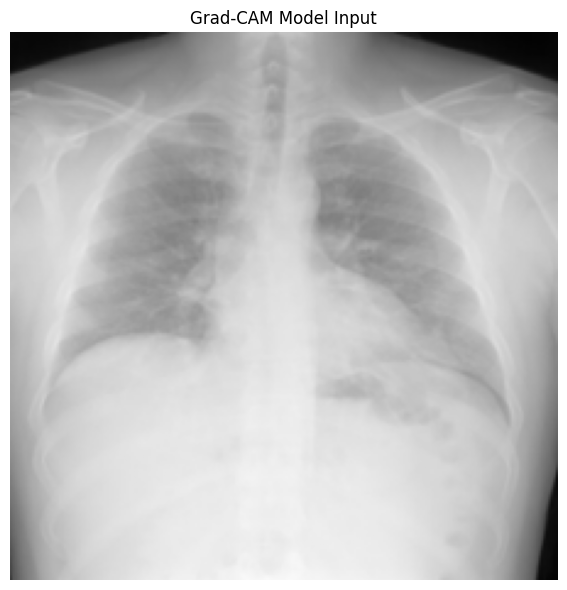

In [40]:
plt.figure(figsize=(6, 6))

plt.imshow(
    processed_image
)

plt.title(
    "Grad-CAM Model Input"
)

plt.axis("off")

plt.tight_layout()

sample_input_path = (
    GRADCAM_VISUALIZATION_DIR
    / "sample_model_input.png"
)

plt.savefig(
    sample_input_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [41]:
def predict_image(
    input_tensor
):

    probabilities = model.predict(
        input_tensor,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(probabilities)
    )

    predicted_class = (
        INDEX_TO_CLASS[
            predicted_index
        ]
    )

    confidence = float(
        probabilities[
            predicted_index
        ]
    )

    return (
        probabilities,
        predicted_index,
        predicted_class,
        confidence
    )


In [42]:
probabilities, predicted_index, predicted_class, confidence = (
    predict_image(
        input_tensor
    )
)

print(
    "Predicted class:",
    predicted_class
)

print(
    "Predicted index:",
    predicted_index
)

print(
    "Confidence:",
    f"{confidence:.4f}"
)

print(
    "\nClass probabilities:"
)

for index, class_name in enumerate(
    CLASS_NAMES
):

    print(
        f"{class_name}: "
        f"{probabilities[index]:.4f}"
    )


Predicted class: COVID-19
Predicted index: 0
Confidence: 0.9101

Class probabilities:
COVID-19: 0.9101
Non-COVID Infection: 0.0160
Normal: 0.0739


In [43]:
def make_gradcam_heatmap(
    input_tensor,
    grad_model,
    target_class_index=None
):

    input_tensor = tf.cast(
        input_tensor,
        tf.float32
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = (
            grad_model(
                input_tensor,
                training=False
            )
        )

        if target_class_index is None:

            target_class_index = tf.argmax(
                predictions[0]
            )

        target_class_index = tf.cast(
            target_class_index,
            tf.int32
        )

        class_channel = predictions[
            0,
            target_class_index
        ]

    gradients = tape.gradient(
        class_channel,
        conv_outputs
    )

    if gradients is None:

        raise RuntimeError(
            "Gradients are None. "
            "The selected layer may not be connected "
            "to the classification output."
        )

    # Global average pooling of gradients
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    # Weighted feature maps
    weighted_features = (
        conv_outputs
        * pooled_gradients
    )

    heatmap = tf.reduce_sum(
        weighted_features,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(
        heatmap
    )

    heatmap = heatmap / (
        max_value + tf.keras.backend.epsilon()
    )

    return (
        heatmap.numpy(),
        int(target_class_index.numpy())
    )


In [48]:
def make_gradcam_heatmap_nested(
    input_tensor,
    model,
    sub_model_layer_name="densenet121",
    target_conv_layer_name="conv5_block16_concat",
    target_class_index=None
):
    input_tensor = tf.cast(input_tensor, tf.float32)

    sub_model = model.get_layer(sub_model_layer_name)
    target_conv_layer = sub_model.get_layer(target_conv_layer_name)

    sub_grad_model = tf.keras.models.Model(
        inputs=sub_model.inputs,
        outputs=[target_conv_layer.output, sub_model.output]
    )

    with tf.GradientTape() as tape:
        x = input_tensor
        for layer in model.layers:
            if layer.name == sub_model_layer_name:
                break
            if isinstance(layer, tf.keras.layers.InputLayer):
                continue
            x = layer(x)

        tape.watch(x)
        conv_outputs, sub_model_predictions = sub_grad_model(x, training=False)

        predictions = sub_model_predictions
        reached_sub_model = False
        for layer in model.layers:
            if layer.name == sub_model_layer_name:
                reached_sub_model = True
                continue
            if reached_sub_model:
                predictions = layer(predictions, training=False)

        if target_class_index is None:
            target_class_index = tf.argmax(predictions[0])

        target_class_index = tf.cast(target_class_index, tf.int32)
        class_channel = predictions[0, target_class_index]

    gradients = tape.gradient(class_channel, conv_outputs)

    if gradients is None:
        raise RuntimeError("Gradients are None. The target layer may not be connected to the output.")

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    weighted_features = conv_outputs * pooled_gradients
    heatmap = tf.reduce_sum(weighted_features, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_value + tf.keras.backend.epsilon())

    return heatmap.numpy(), int(target_class_index.numpy())

heatmap, target_class_index = make_gradcam_heatmap_nested(
    input_tensor,
    model,
    sub_model_layer_name="densenet121",
    target_conv_layer_name="conv5_block16_concat",
    target_class_index=predicted_index
)

print("Heatmap shape:", heatmap.shape)
print("Heatmap minimum:", heatmap.min())
print("Heatmap maximum:", heatmap.max())
print("Target class:", INDEX_TO_CLASS[target_class_index])

Heatmap shape: (7, 7)
Heatmap minimum: 0.0
Heatmap maximum: 0.9999936
Target class: COVID-19


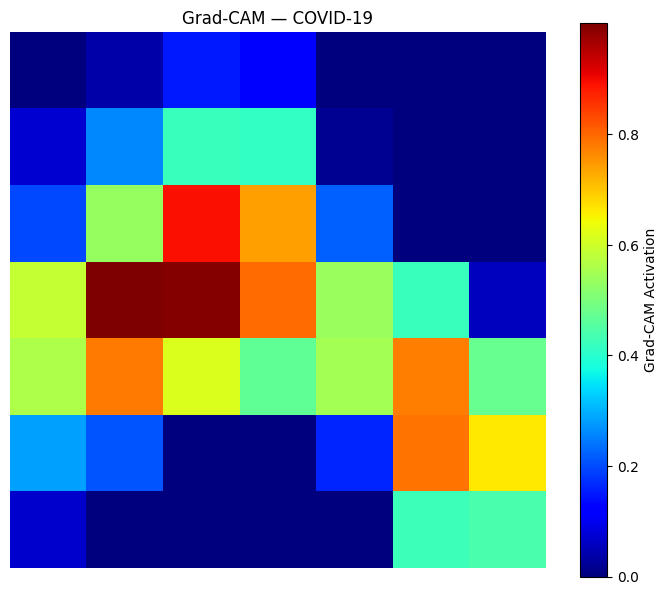

In [49]:
plt.figure(figsize=(7, 6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar(
    label="Grad-CAM Activation"
)

plt.title(
    f"Grad-CAM — {predicted_class}"
)

plt.axis("off")

plt.tight_layout()

raw_heatmap_path = (
    GRADCAM_HEATMAP_DIR
    / "sample_heatmap.png"
)

plt.savefig(
    raw_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [50]:
def resize_heatmap(
    heatmap,
    target_width,
    target_height
):

    heatmap_resized = cv2.resize(
        heatmap,
        (
            target_width,
            target_height
        ),
        interpolation=cv2.INTER_LINEAR
    )

    return heatmap_resized


heatmap_resized = resize_heatmap(

    heatmap,

    processed_image.shape[1],

    processed_image.shape[0]

)

print(
    "Resized heatmap shape:",
    heatmap_resized.shape
)


Resized heatmap shape: (224, 224)


In [51]:
def heatmap_to_color(
    heatmap,
    colormap=HEATMAP_COLORMAP
):

    heatmap_uint8 = np.uint8(
        255 * heatmap
    )

    colored_heatmap = cv2.applyColorMap(
        heatmap_uint8,
        colormap
    )

    colored_heatmap = cv2.cvtColor(
        colored_heatmap,
        cv2.COLOR_BGR2RGB
    )

    return colored_heatmap


colored_heatmap = heatmap_to_color(
    heatmap_resized
)

print(
    "Colored heatmap shape:",
    colored_heatmap.shape
)



Colored heatmap shape: (224, 224, 3)


In [52]:
def create_gradcam_overlay(
    image,
    heatmap,
    alpha=ALPHA
):

    image_uint8 = np.uint8(
        np.clip(
            image * 255.0,
            0,
            255
        )
    )
    heatmap_resized = cv2.resize(
        heatmap,
        (
            image_uint8.shape[1],
            image_uint8.shape[0]
        ),
        interpolation=cv2.INTER_LINEAR
    )

    heatmap_color = heatmap_to_color(
        heatmap_resized
    )

    overlay = cv2.addWeighted(
        image_uint8,
        1.0 - alpha,
        heatmap_color,
        alpha,
        0
    )

    return overlay


overlay = create_gradcam_overlay(
    processed_image,
    heatmap,
    alpha=ALPHA
)

print(
    "Overlay shape:",
    overlay.shape
)


Overlay shape: (224, 224, 3)


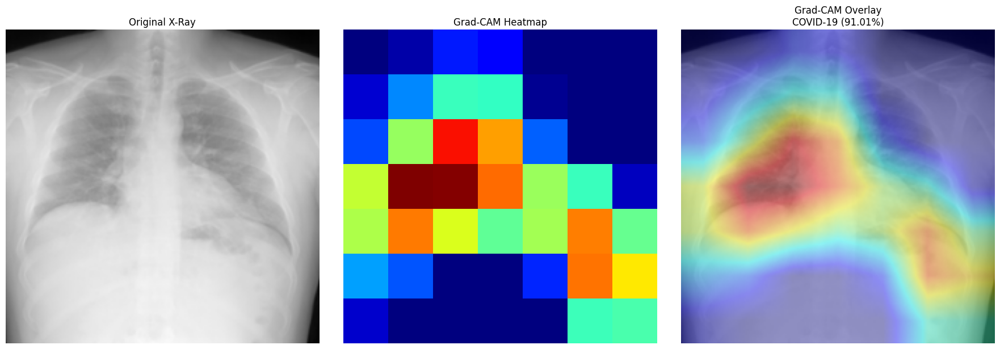

In [53]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)

plt.imshow(
    processed_image
)

plt.title(
    "Original X-Ray"
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.title(
    "Grad-CAM Heatmap"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    overlay
)

plt.title(
    f"Grad-CAM Overlay\n"
    f"{predicted_class} "
    f"({confidence:.2%})"
)

plt.axis("off")


plt.tight_layout()

sample_comparison_path = (
    GRADCAM_VISUALIZATION_DIR
    / "sample_gradcam_comparison.png"
)

plt.savefig(
    sample_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [54]:
sample_id = str(
    test_df.iloc[0]["sample_id"]
)

original_save_path = (
    GRADCAM_IMAGES_DIR
    / f"{sample_id}_original.png"
)

heatmap_save_path = (
    GRADCAM_HEATMAP_DIR
    / f"{sample_id}_heatmap.png"
)

overlay_save_path = (
    GRADCAM_OVERLAY_DIR
    / f"{sample_id}_overlay.png"
)

Image.fromarray(
    np.uint8(
        np.clip(
            processed_image * 255,
            0,
            255
        )
    )
).save(
    original_save_path
)

Image.fromarray(
    colored_heatmap
).save(
    heatmap_save_path
)

Image.fromarray(
    overlay
).save(
    overlay_save_path
)

print(
    "Single sample Grad-CAM artifacts saved."
)


Single sample Grad-CAM artifacts saved.


In [56]:
target_class_for_demo = CLASS_TO_INDEX[
    "COVID-19"
]

covid_heatmap, covid_target_index = (
    make_gradcam_heatmap_nested(
        input_tensor,
        model,
        sub_model_layer_name="densenet121",
        target_conv_layer_name="conv5_block16_concat",
        target_class_index=target_class_for_demo
    )
)

print(
    "Requested target class:",
    INDEX_TO_CLASS[
        covid_target_index
    ]
)

Requested target class: COVID-19


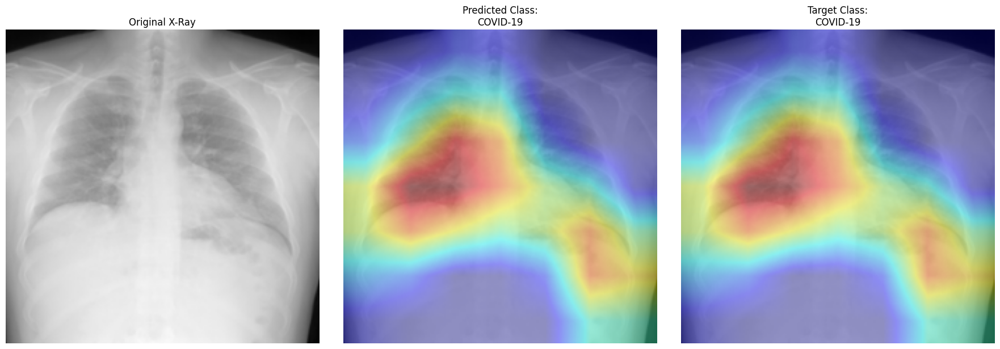

In [57]:
predicted_heatmap_resized = cv2.resize(
    heatmap,
    IMAGE_SIZE,
    interpolation=cv2.INTER_LINEAR
)

covid_heatmap_resized = cv2.resize(
    covid_heatmap,
    IMAGE_SIZE,
    interpolation=cv2.INTER_LINEAR
)

predicted_overlay = create_gradcam_overlay(
    processed_image,
    predicted_heatmap_resized,
    alpha=ALPHA
)

covid_overlay = create_gradcam_overlay(
    processed_image,
    covid_heatmap_resized,
    alpha=ALPHA
)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)

plt.imshow(
    processed_image
)

plt.title(
    "Original X-Ray"
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    predicted_overlay
)

plt.title(
    f"Predicted Class:\n{predicted_class}"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    covid_overlay
)

plt.title(
    "Target Class:\nCOVID-19"
)

plt.axis("off")


plt.tight_layout()

target_comparison_path = (
    GRADCAM_VISUALIZATION_DIR
    / "predicted_vs_target_gradcam.png"
)

plt.savefig(
    target_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [59]:
MAX_IMAGES = None

if MAX_IMAGES is None:
    gradcam_test_df = test_df.copy()
else:
    gradcam_test_df = (
        test_df.head(MAX_IMAGES)
        .copy()
    )

gradcam_records = []

print(
    "Generating Grad-CAM for",
    len(gradcam_test_df),
    "test images..."
)

for row_number, row in enumerate(
    gradcam_test_df.itertuples(),
    start=1
):
    image_path = Path(
        row.resolved_path
    )
    sample_id = str(
        row.sample_id
    )

    if hasattr(row, "class_name"):
        true_class = str(row.class_name)
    elif hasattr(row, "_asdict"):
        true_class = str(row._asdict().get("class", ""))
    else:
        true_class = "Unknown"

    original_image, processed_image, input_tensor = (
        load_and_preprocess_image(
            image_path
        )
    )

    probabilities, predicted_index, predicted_class, confidence = (
        predict_image(
            input_tensor
        )
    )

    heatmap, target_index = (
        make_gradcam_heatmap_nested(
            input_tensor,
            model,
            sub_model_layer_name="densenet121",
            target_conv_layer_name="conv5_block16_concat",
            target_class_index=predicted_index
        )
    )

    heatmap_resized = cv2.resize(
        heatmap,
        (
            processed_image.shape[1],
            processed_image.shape[0]
        ),
        interpolation=cv2.INTER_LINEAR
    )

    colored_heatmap = heatmap_to_color(
        heatmap_resized
    )

    overlay = create_gradcam_overlay(
        processed_image,
        heatmap_resized,
        alpha=ALPHA
    )

    safe_id = "".join(
        character
        if character.isalnum()
        or character in "-_"
        else "_"
        for character in sample_id
    )

    original_output_path = (
        GRADCAM_IMAGES_DIR
        / f"{safe_id}_original.png"
    )
    Image.fromarray(
        np.uint8(
            np.clip(
                processed_image * 255,
                0,
                255
            )
        )
    ).save(
        original_output_path
    )

    heatmap_output_path = (
        GRADCAM_HEATMAP_DIR
        / f"{safe_id}_heatmap.png"
    )
    Image.fromarray(
        colored_heatmap
    ).save(
        heatmap_output_path
    )

    overlay_output_path = (
        GRADCAM_OVERLAY_DIR
        / f"{safe_id}_overlay.png"
    )
    Image.fromarray(
        overlay
    ).save(
        overlay_output_path
    )

    record = {
        "sample_id": sample_id,
        "image_path": str(
            image_path
        ),
        "true_class": true_class,
        "predicted_class": predicted_class,
        "true_class_index": (
            CLASS_TO_INDEX.get(
                true_class,
                None
            )
        ),
        "predicted_class_index": (
            predicted_index
        ),
        "confidence": confidence,
        "target_class": predicted_class,
        "target_class_index": predicted_index,
        "gradcam_layer": LAST_CONV_LAYER_NAME,
        "image_width": int(
            processed_image.shape[1]
        ),
        "image_height": int(
            processed_image.shape[0]
        ),
        "original_output": str(
            original_output_path
        ),
        "heatmap_output": str(
            heatmap_output_path
        ),
        "overlay_output": str(
            overlay_output_path
        )
    }

    for index, class_name in enumerate(
        CLASS_NAMES
    ):
        safe_class_name = (
            class_name
            .lower()
            .replace("-", "")
            .replace(" ", "_")
        )
        record[
            f"probability_{safe_class_name}"
        ] = float(
            probabilities[index]
        )

    gradcam_records.append(
        record
    )

    if (
        row_number % 100 == 0
        or row_number == len(gradcam_test_df)
    ):
        print(
            f"Processed "
            f"{row_number}/"
            f"{len(gradcam_test_df)}"
        )


Generating Grad-CAM for 6788 test images...
Processed 100/6788
Processed 200/6788
Processed 300/6788
Processed 400/6788
Processed 500/6788
Processed 600/6788
Processed 700/6788
Processed 800/6788
Processed 900/6788
Processed 1000/6788
Processed 1100/6788
Processed 1200/6788
Processed 1300/6788
Processed 1400/6788
Processed 1500/6788
Processed 1600/6788
Processed 1700/6788
Processed 1800/6788
Processed 1900/6788
Processed 2000/6788
Processed 2100/6788
Processed 2200/6788
Processed 2300/6788
Processed 2400/6788
Processed 2500/6788
Processed 2600/6788
Processed 2700/6788
Processed 2800/6788
Processed 2900/6788
Processed 3000/6788
Processed 3100/6788
Processed 3200/6788
Processed 3300/6788
Processed 3400/6788
Processed 3500/6788
Processed 3600/6788
Processed 3700/6788
Processed 3800/6788
Processed 3900/6788
Processed 4000/6788
Processed 4100/6788
Processed 4200/6788
Processed 4300/6788
Processed 4400/6788
Processed 4500/6788
Processed 4600/6788
Processed 4700/6788
Processed 4800/6788
Proce

In [60]:
gradcam_results_df = pd.DataFrame(
    gradcam_records
)

gradcam_results_path = (
    GRADCAM_REPORT_DIR
    / "gradcam_results.csv"
)

gradcam_results_df.to_csv(
    gradcam_results_path,
    index=False
)

print(
    "\nGrad-CAM results saved:"
)

print(
    gradcam_results_path
)

print(
    "\nResult shape:",
    gradcam_results_df.shape
)



Grad-CAM results saved:
/content/gradcam_results/reports/gradcam_results.csv

Result shape: (6788, 18)


In [61]:
print(
    "\nPrediction distribution:"
)

print(
    gradcam_results_df[
        "predicted_class"
    ].value_counts()
)

print(
    "\nTrue class distribution:"
)

print(
    gradcam_results_df[
        "true_class"
    ].value_counts()
)



Prediction distribution:
predicted_class
COVID-19               2347
Non-COVID Infection    2232
Normal                 2209
Name: count, dtype: int64

True class distribution:
true_class
COVID-19               2395
Non-COVID Infection    2253
Normal                 2140
Name: count, dtype: int64


In [62]:
gradcam_results_df[
    "prediction_correct"
] = (

    gradcam_results_df[
        "true_class"
    ]

    ==

    gradcam_results_df[
        "predicted_class"
    ]

)

correct_count = int(
    gradcam_results_df[
        "prediction_correct"
    ].sum()
)

incorrect_count = (
    len(gradcam_results_df)
    - correct_count
)

gradcam_accuracy = (
    correct_count
    / len(gradcam_results_df)
)

print(
    "Correct predictions:",
    correct_count
)

print(
    "Incorrect predictions:",
    incorrect_count
)

print(
    "Accuracy:",
    f"{gradcam_accuracy:.4f}"
)


Correct predictions: 6345
Incorrect predictions: 443
Accuracy: 0.9347


In [63]:
gradcam_results_df.to_csv(
    gradcam_results_path,
    index=False
)


In [64]:
NUM_CORRECT_EXAMPLES = 6
NUM_INCORRECT_EXAMPLES = 6

correct_examples = (
    gradcam_results_df[
        gradcam_results_df[
            "prediction_correct"
        ]
    ]
    .sample(
        min(
            NUM_CORRECT_EXAMPLES,
            correct_count
        ),
        random_state=SEED
    )
)

incorrect_examples = (
    gradcam_results_df[
        ~gradcam_results_df[
            "prediction_correct"
        ]
    ]
    .sample(
        min(
            NUM_INCORRECT_EXAMPLES,
            incorrect_count
        ),
        random_state=SEED
    )
)

print(
    "Correct examples:",
    len(correct_examples)
)

print(
    "Incorrect examples:",
    len(incorrect_examples)
)



Correct examples: 6
Incorrect examples: 6


In [65]:
def display_saved_gradcam_result(
    result_row
):

    original_path = Path(
        result_row[
            "original_output"
        ]
    )

    heatmap_path = Path(
        result_row[
            "heatmap_output"
        ]
    )

    overlay_path = Path(
        result_row[
            "overlay_output"
        ]
    )

    original = np.array(
        Image.open(
            original_path
        )
    )

    heatmap = np.array(
        Image.open(
            heatmap_path
        )
    )

    overlay = np.array(
        Image.open(
            overlay_path
        )
    )

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)

    plt.imshow(
        original
    )

    plt.title(
        f"Original\n"
        f"True: {result_row['true_class']}"
    )

    plt.axis("off")

    plt.subplot(1, 3, 2)

    plt.imshow(
        heatmap
    )

    plt.title(
        "Grad-CAM Heatmap"
    )

    plt.axis("off")

    plt.subplot(1, 3, 3)

    plt.imshow(
        overlay
    )

    plt.title(
        f"Prediction: "
        f"{result_row['predicted_class']}\n"
        f"Confidence: "
        f"{result_row['confidence']:.2%}"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()



CORRECT PREDICTION EXAMPLES


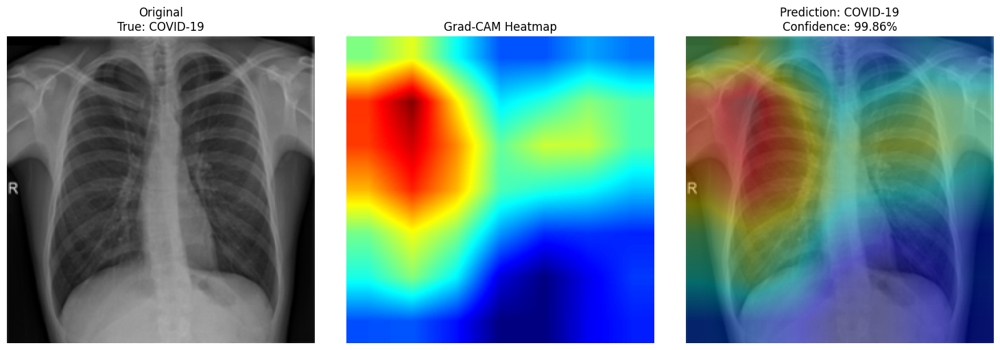

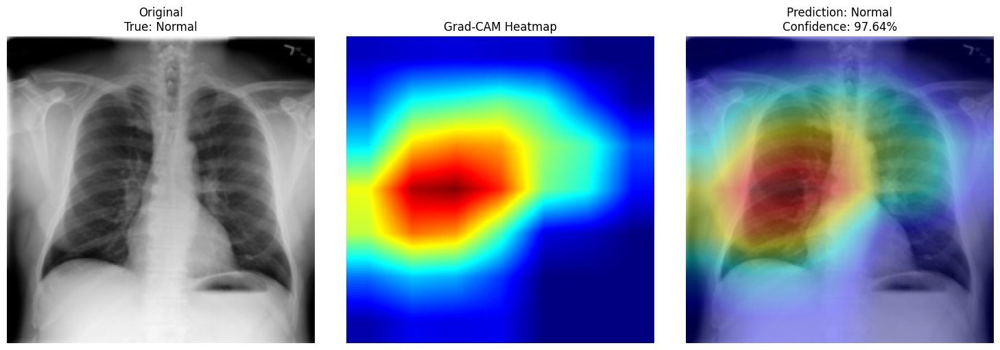

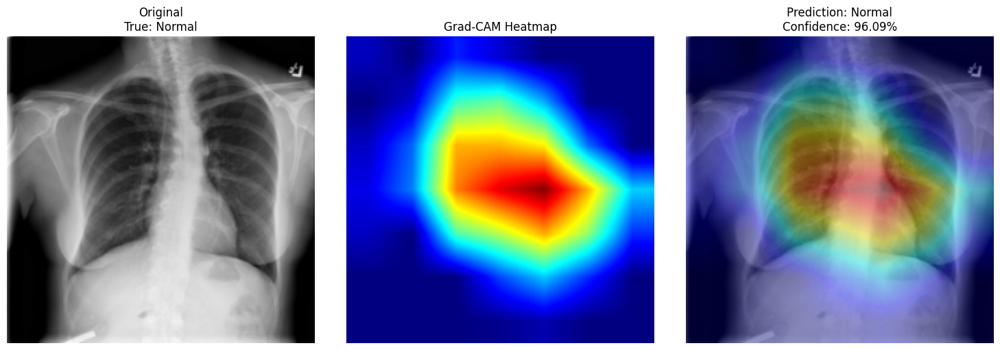

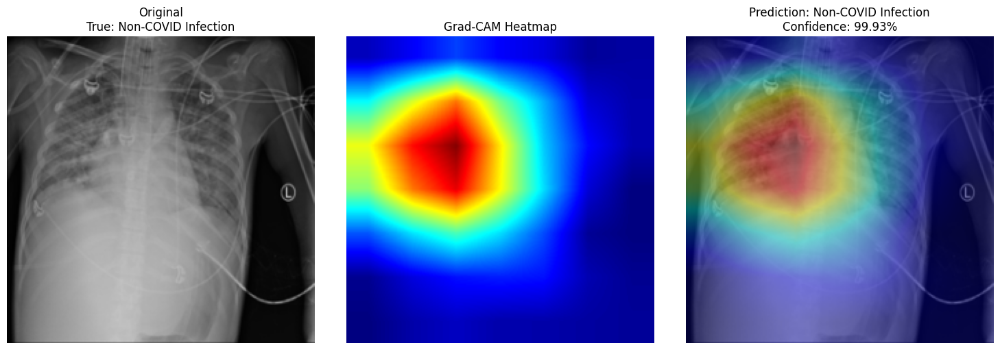

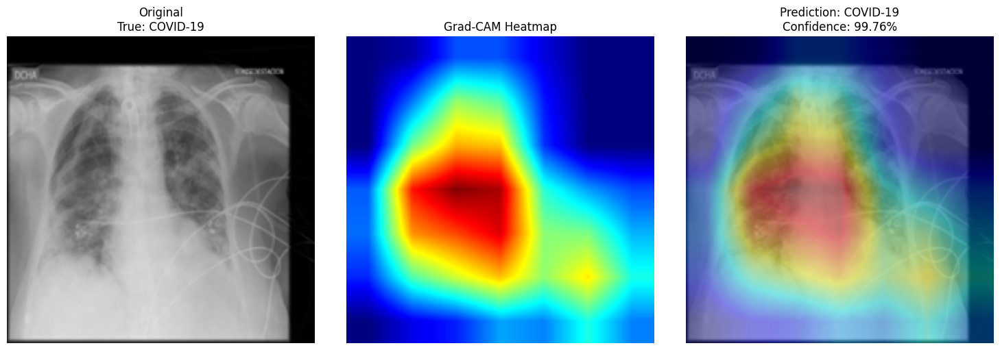

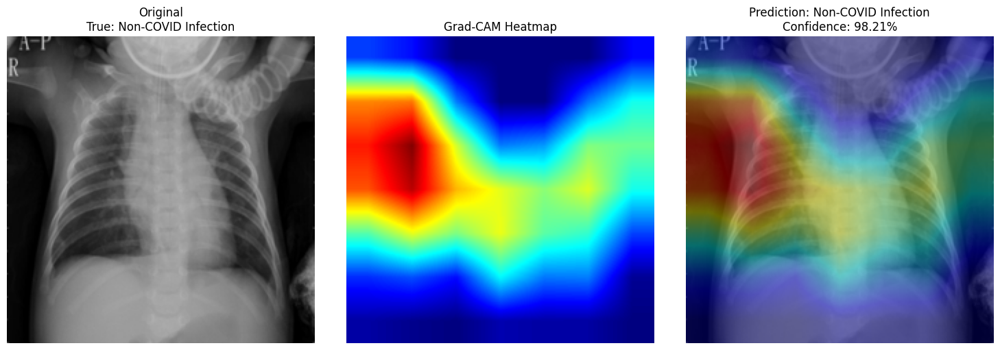

In [66]:
print(
    "\nCORRECT PREDICTION EXAMPLES"
)

for _, example in correct_examples.iterrows():

    display_saved_gradcam_result(
        example
    )




INCORRECT PREDICTION EXAMPLES


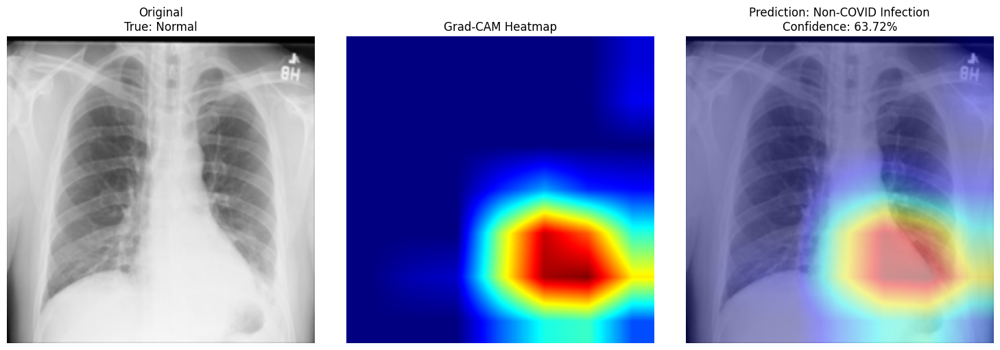

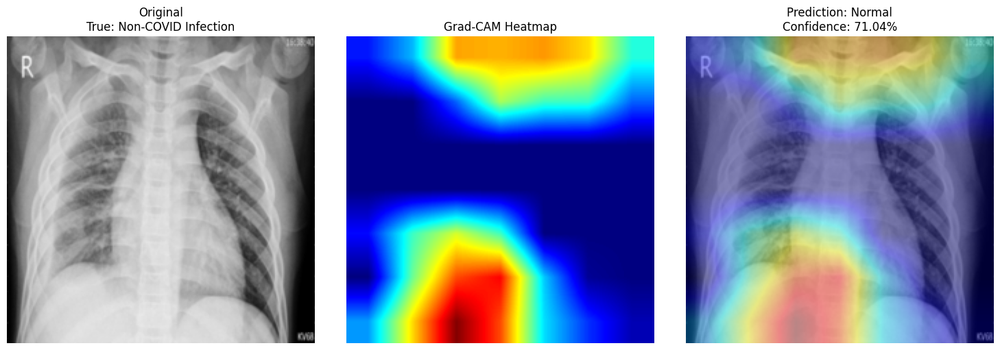

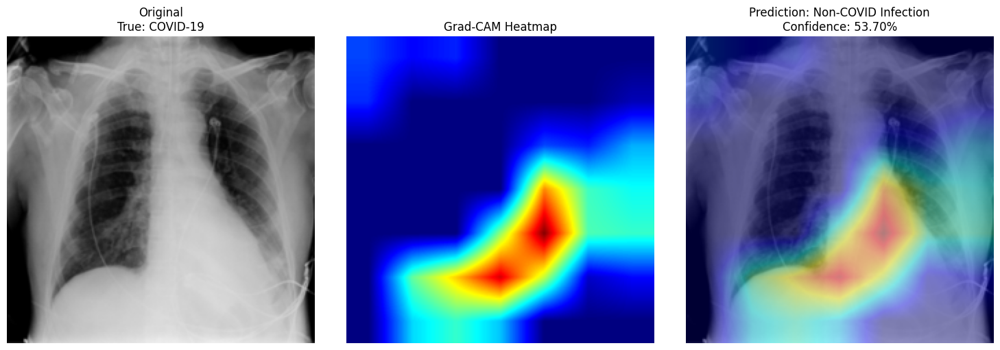

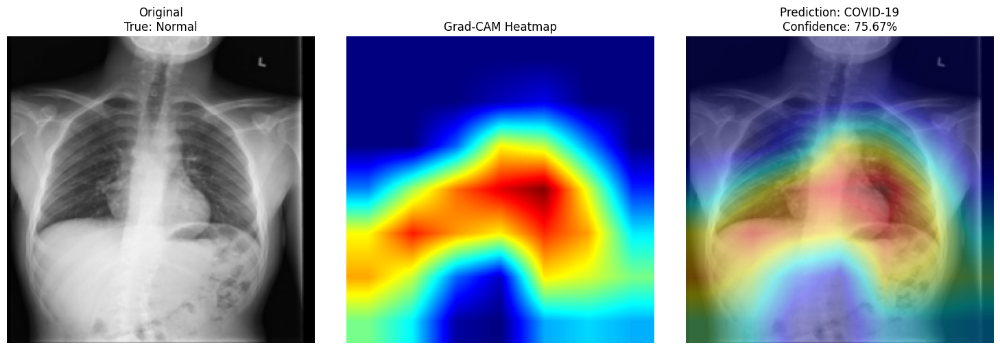

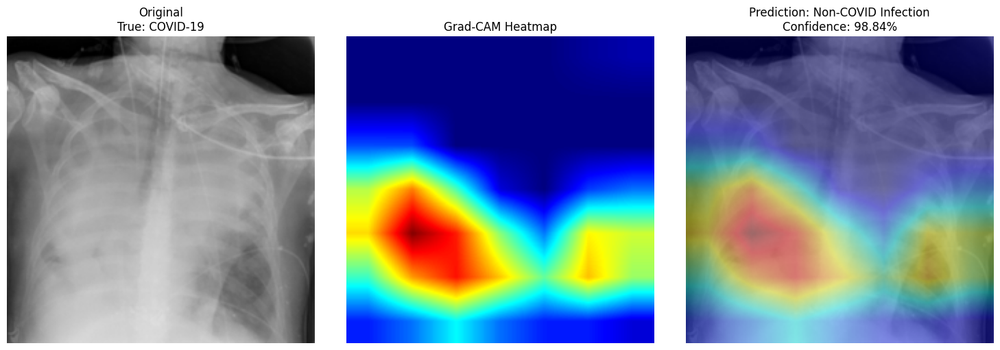

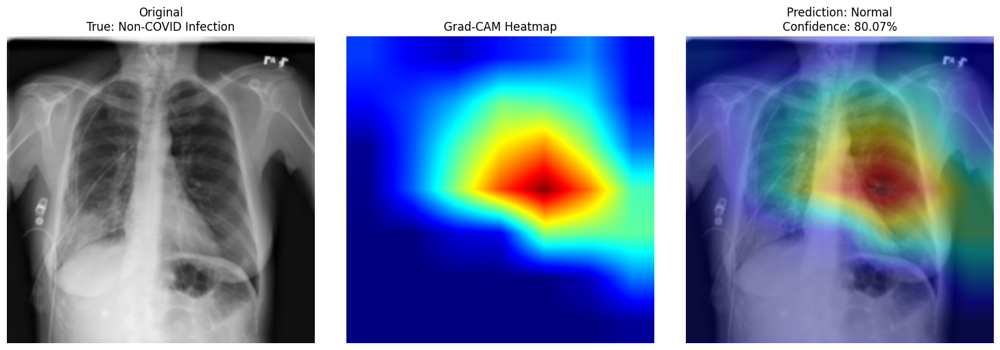

In [67]:
print(
    "\nINCORRECT PREDICTION EXAMPLES"
)

for _, example in incorrect_examples.iterrows():

    display_saved_gradcam_result(
        example
    )


In [68]:
correct_examples.to_csv(

    GRADCAM_REPORT_DIR
    / "correct_gradcam_examples.csv",

    index=False
)

incorrect_examples.to_csv(

    GRADCAM_REPORT_DIR
    / "incorrect_gradcam_examples.csv",

    index=False
)


In [69]:
class_summary = (
    gradcam_results_df
    .groupby("true_class")
    .agg(
        samples=("sample_id", "count"),
        accuracy=("prediction_correct", "mean"),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

class_summary_path = (
    GRADCAM_REPORT_DIR
    / "gradcam_class_summary.csv"
)

class_summary.to_csv(
    class_summary_path,
    index=False
)

print(
    class_summary
)

            true_class  samples  accuracy  mean_confidence
0             COVID-19     2395  0.946138         0.942532
1  Non-COVID Infection     2253  0.921438         0.931312
2               Normal     2140  0.935981         0.888827


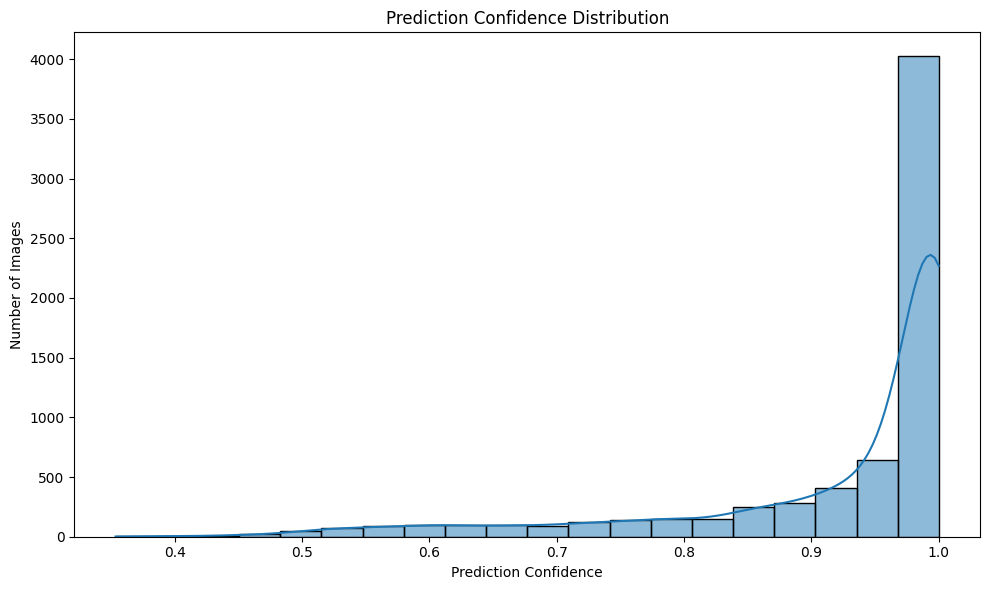

In [70]:
plt.figure(figsize=(10, 6))

sns.histplot(
    gradcam_results_df[
        "confidence"
    ],
    bins=20,
    kde=True
)

plt.title(
    "Prediction Confidence Distribution"
)

plt.xlabel(
    "Prediction Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.tight_layout()

confidence_plot_path = (
    GRADCAM_REPORT_DIR
    / "confidence_distribution.png"
)

plt.savefig(
    confidence_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [71]:
LOW_CONFIDENCE_THRESHOLD = 0.60

low_confidence_df = (
    gradcam_results_df[
        gradcam_results_df[
            "confidence"
        ]
        < LOW_CONFIDENCE_THRESHOLD
    ]
    .sort_values(
        "confidence"
    )
)

low_confidence_path = (
    GRADCAM_REPORT_DIR
    / "low_confidence_predictions.csv"
)

low_confidence_df.to_csv(
    low_confidence_path,
    index=False
)

print(
    "Low-confidence predictions:",
    len(low_confidence_df)
)


Low-confidence predictions: 296


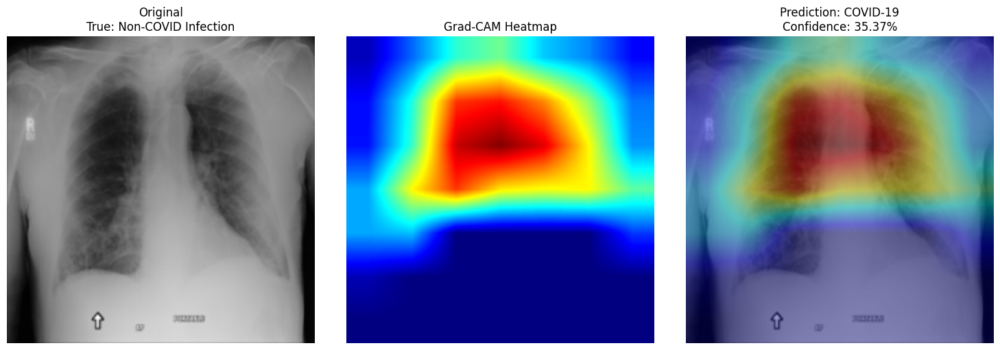

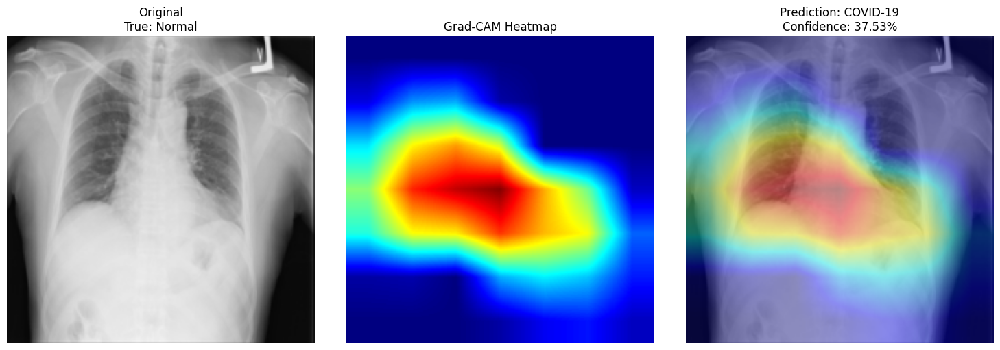

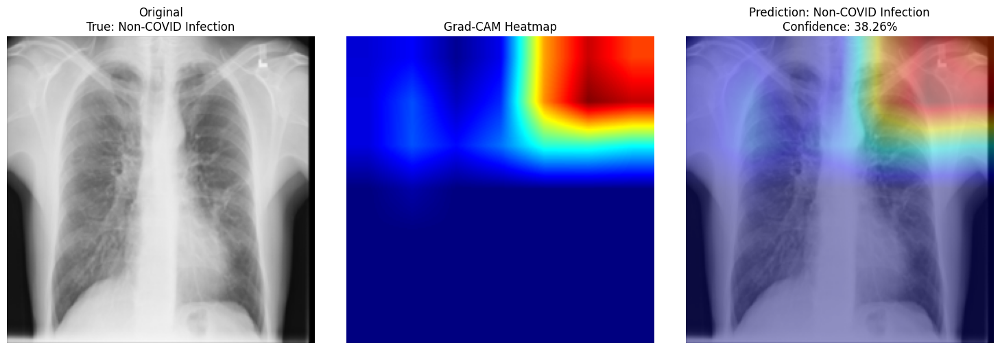

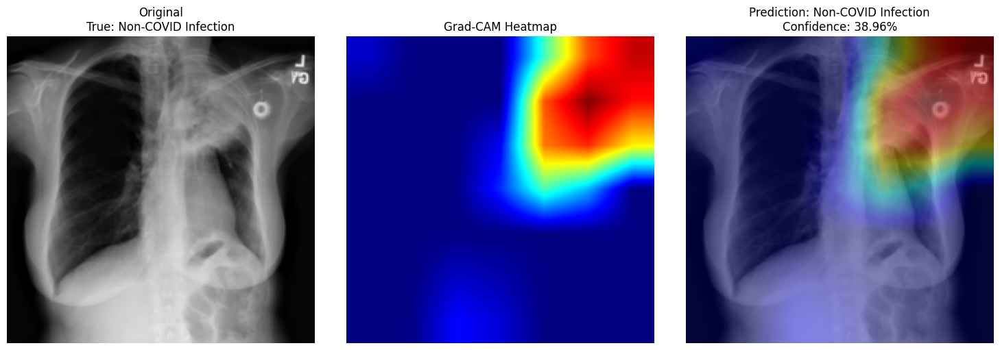

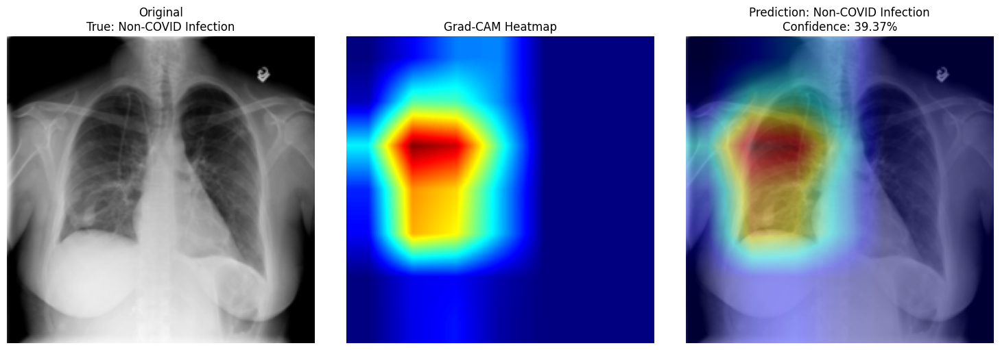

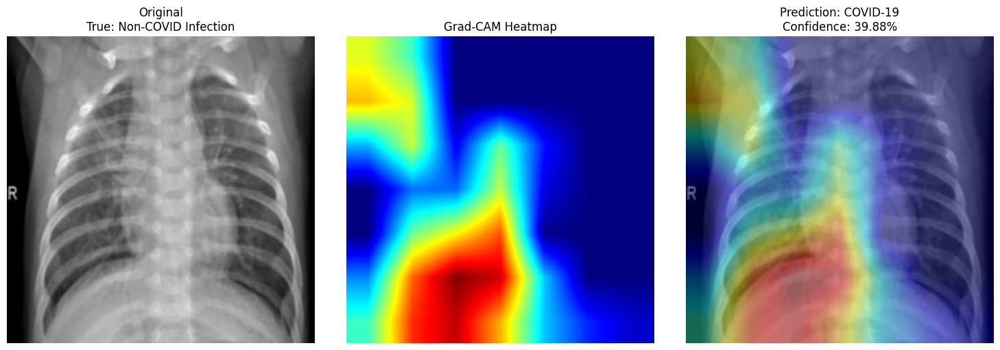

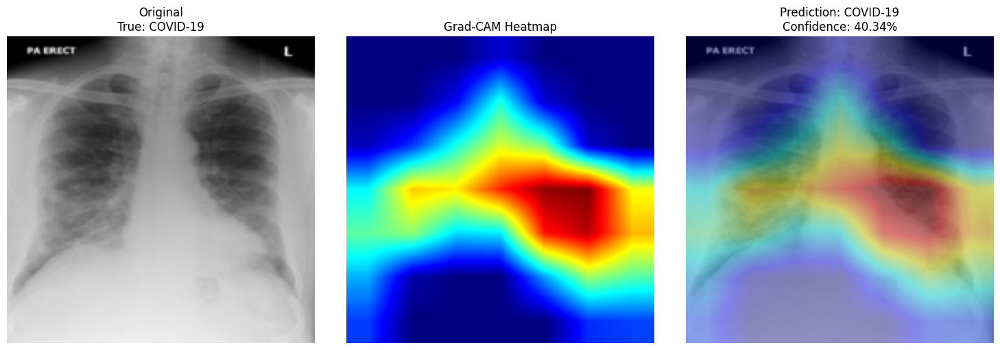

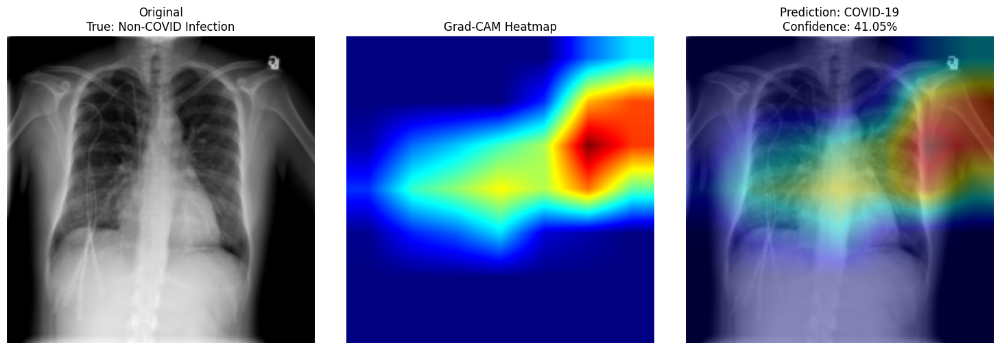

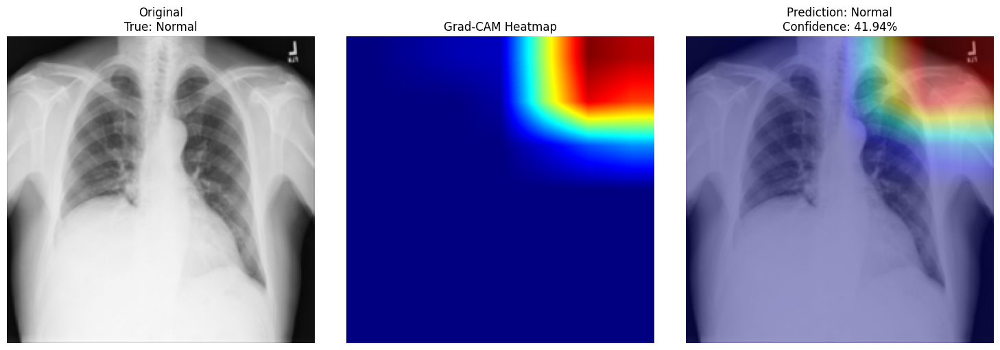

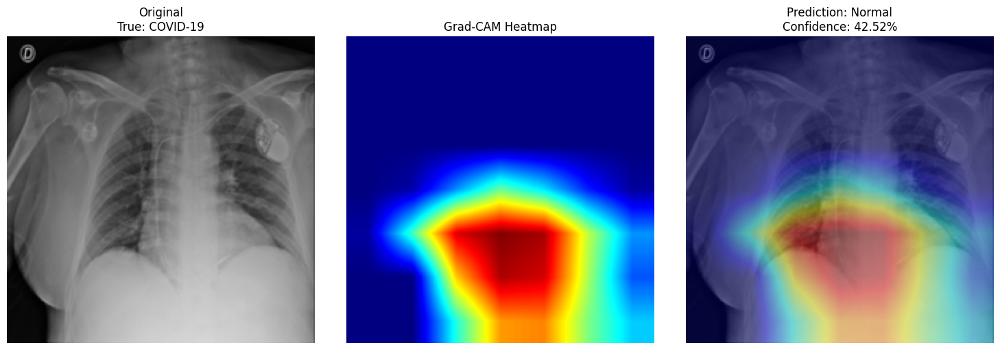

In [72]:
NUM_LOW_CONFIDENCE_EXAMPLES = min(
    10,
    len(low_confidence_df)
)

if NUM_LOW_CONFIDENCE_EXAMPLES > 0:

    selected_low_confidence = (
        low_confidence_df
        .head(
            NUM_LOW_CONFIDENCE_EXAMPLES
        )
    )

    for _, example in (
        selected_low_confidence.iterrows()
    ):

        display_saved_gradcam_result(
            example
        )


In [73]:
high_confidence_wrong_df = (
    gradcam_results_df[
        (
            ~gradcam_results_df[
                "prediction_correct"
            ]
        )
        &
        (
            gradcam_results_df[
                "confidence"
            ]
            >= 0.80
        )
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
)

high_confidence_wrong_path = (
    GRADCAM_REPORT_DIR
    / "high_confidence_wrong_predictions.csv"
)

high_confidence_wrong_df.to_csv(
    high_confidence_wrong_path,
    index=False
)

print(
    "High-confidence incorrect predictions:",
    len(high_confidence_wrong_df)
)


High-confidence incorrect predictions: 151


In [74]:
gradcam_metadata = {

    "project":
        "Medical Image Analysis Assistant",

    "dataset":
        "COVID-QU-Ex",

    "model":
        MODEL_NAME,

    "model_path":
        str(MODEL_PATH),

    "gradcam_method":
        "Grad-CAM",

    "gradcam_layer":
        LAST_CONV_LAYER_NAME,

    "input_size":
        list(IMAGE_SIZE),

    "normalization":
        NORMALIZATION,

    "alpha":
        ALPHA,

    "heatmap_colormap":
        "COLORMAP_JET",

    "classes":
        CLASS_NAMES,

    "test_samples":
        int(len(gradcam_results_df)),

    "correct_predictions":
        correct_count,

    "incorrect_predictions":
        incorrect_count,

    "gradcam_accuracy":
        float(gradcam_accuracy),

    "low_confidence_threshold":
        LOW_CONFIDENCE_THRESHOLD,

    "purpose":
        (
            "Post-hoc visual explanation of DenseNet121 "
            "classification predictions."
        ),

    "important_limitation":
        (
            "Grad-CAM highlights image regions associated "
            "with the model prediction. It does not establish "
            "clinical causality, lesion presence, or diagnostic validity."
        )

}

metadata_path = (
    GRADCAM_METADATA_DIR
    / "gradcam_config.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        gradcam_metadata,
        file,
        indent=4
    )

print(
    "Grad-CAM metadata saved."
)


Grad-CAM metadata saved.


In [75]:
layer_information = []

for index, layer in enumerate(
    model.layers
):

    layer_information.append({

        "index": index,

        "name": layer.name,

        "type": layer.__class__.__name__,

        "trainable": bool(
            layer.trainable
        ),

        "output_shape": str(
            getattr(
                layer,
                "output_shape",
                "N/A"
            )
        )

    })


layer_information_df = pd.DataFrame(
    layer_information
)

layer_information_path = (
    GRADCAM_METADATA_DIR
    / "model_layers.csv"
)

layer_information_df.to_csv(
    layer_information_path,
    index=False
)


In [76]:
readme_text = f"""
Medical Image Analysis Assistant
=================================

Grad-CAM Explainability Results
--------------------------------

Model:
{MODEL_NAME}

Model file:
{MODEL_PATH}

Grad-CAM layer:
{LAST_CONV_LAYER_NAME}

Input size:
{IMAGE_SIZE}

Normalization:
{NORMALIZATION}

Classes:
{CLASS_NAMES}

Test samples processed:
{len(gradcam_results_df)}

Correct predictions:
{correct_count}

Incorrect predictions:
{incorrect_count}

Grad-CAM accuracy:
{gradcam_accuracy:.4f}

Directory structure
-------------------

images/
    Preprocessed model inputs.

heatmaps/
    Raw Grad-CAM heatmap images.

overlays/
    Grad-CAM heatmaps overlaid on X-rays.

visualizations/
    Side-by-side explainability figures.

reports/
    Prediction results, summaries and analysis tables.

predictions/
    Prediction-related outputs.

metadata/
    Model and Grad-CAM configuration.

Important interpretation note
-----------------------------

Grad-CAM is a post-hoc visual explanation method.

The highlighted regions indicate areas that contributed
to the model's target-class activation.

They should NOT be interpreted as:

    - a clinical diagnosis
    - a lesion segmentation
    - proof of disease
    - proof of model correctness
    - proof of causal reasoning

For a production medical AI system, Grad-CAM should be
treated as an explainability / research-support component
rather than an autonomous diagnostic mechanism.
"""

readme_path = (
    GRADCAM_DIR
    / "README.txt"
)

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        readme_text
    )

print(
    "README created."
)


README created.


In [77]:
final_report = {

    "model": MODEL_NAME,

    "test_samples": len(
        gradcam_results_df
    ),

    "accuracy": float(
        gradcam_accuracy
    ),

    "correct": correct_count,

    "incorrect": incorrect_count,

    "mean_confidence": float(
        gradcam_results_df[
            "confidence"
        ].mean()
    ),

    "median_confidence": float(
        gradcam_results_df[
            "confidence"
        ].median()
    ),

    "minimum_confidence": float(
        gradcam_results_df[
            "confidence"
        ].min()
    ),

    "maximum_confidence": float(
        gradcam_results_df[
            "confidence"
        ].max()
    ),

    "low_confidence_samples": int(
        len(low_confidence_df)
    ),

    "high_confidence_wrong_predictions": int(
        len(high_confidence_wrong_df)
    ),

    "gradcam_layer": LAST_CONV_LAYER_NAME

}

final_report_path = (
    GRADCAM_REPORT_DIR
    / "final_gradcam_report.json"
)

with open(
    final_report_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_report,
        file,
        indent=4
    )

print(
    "Final Grad-CAM report saved."
)


Final Grad-CAM report saved.


In [ ]:
print("GRAD-CAM EXPLAINABILITY COMPLETE")
print(
    "\nModel:",
    MODEL_NAME
)

print(
    "Grad-CAM layer:",
    LAST_CONV_LAYER_NAME
)

print(
    "Test images processed:",
    len(gradcam_results_df)
)

print(
    "Correct predictions:",
    correct_count
)

print(
    "Incorrect predictions:",
    incorrect_count
)

print(
    "Accuracy:",
    f"{gradcam_accuracy:.4f}"
)

print(
    "Mean confidence:",
    f"{gradcam_results_df['confidence'].mean():.4f}"
)

print(
    "Low-confidence cases:",
    len(low_confidence_df)
)

print(
    "High-confidence wrong cases:",
    len(high_confidence_wrong_df)
)



In [78]:
print(
    "\nGrad-CAM output structure:\n"
)

for root, dirs, files in os.walk(
    GRADCAM_DIR
):

    relative_root = (
        Path(root)
        .relative_to(
            GRADCAM_DIR
        )
    )

    indentation = (
        "    "
        * len(
            relative_root.parts
        )
    )

    print(
        f"{indentation}{Path(root).name}/"
    )

    for filename in sorted(files):

        print(
            f"{indentation}    {filename}"
        )


Streaming output truncated to the last 5000 lines.
        Normal__9423__overlay.png
        Normal__9424__overlay.png
        Normal__9425__overlay.png
        Normal__9427__overlay.png
        Normal__9428__overlay.png
        Normal__9429__overlay.png
        Normal__9430__overlay.png
        Normal__9431__overlay.png
        Normal__9432__overlay.png
        Normal__9433__overlay.png
        Normal__9434__overlay.png
        Normal__9435__overlay.png
        Normal__9436__overlay.png
        Normal__9437__overlay.png
        Normal__9438__overlay.png
        Normal__9439__overlay.png
        Normal__9440__overlay.png
        Normal__9441__overlay.png
        Normal__9442__overlay.png
        Normal__9443__overlay.png
        Normal__9444__overlay.png
        Normal__9445__overlay.png
        Normal__9446__overlay.png
        Normal__9447__overlay.png
        Normal__9448__overlay.png
        Normal__9449__overlay.png
        Normal__9450__overlay.png
        Normal__9451__overlay.p

In [79]:
GRADCAM_ZIP_PATH = (
    PROJECT_ROOT
    / "Medical_Image_Analysis_GradCAM_results.zip"
)

if GRADCAM_ZIP_PATH.exists():

    GRADCAM_ZIP_PATH.unlink()


with zipfile.ZipFile(
    GRADCAM_ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for root, dirs, files in os.walk(
        GRADCAM_DIR
    ):

        for filename in files:

            file_path = (
                Path(root)
                / filename
            )

            archive_name = (
                Path(
                    GRADCAM_DIR.name
                )
                / file_path.relative_to(
                    GRADCAM_DIR
                )
            )

            zip_file.write(
                file_path,
                archive_name
            )


print(
    "\nGrad-CAM ZIP created:"
)

print(
    GRADCAM_ZIP_PATH
)

print(
    "ZIP size:",
    round(
        GRADCAM_ZIP_PATH.stat().st_size
        / (1024 ** 2),
        2
    ),
    "MB"
)



Grad-CAM ZIP created:
/content/Medical_Image_Analysis_GradCAM_results.zip
ZIP size: 672.61 MB


In [80]:
try:

    from google.colab import files

    print(
        "Google Colab detected."
    )

    files.download(
        str(GRADCAM_ZIP_PATH)
    )

except ImportError:

    print(
        "\nLocal Jupyter / VS Code environment detected."
    )

    print(
        "ZIP is available at:"
    )

    print(
        GRADCAM_ZIP_PATH
    )


Google Colab detected.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:


required_outputs = [

    GRADCAM_DIR,

    GRADCAM_REPORT_DIR
    / "gradcam_results.csv",

    GRADCAM_REPORT_DIR
    / "final_gradcam_report.json",

    GRADCAM_METADATA_DIR
    / "gradcam_config.json",

    GRADCAM_ZIP_PATH

]

print(
    "\nFinal output validation:\n"
)

all_outputs_exist = True

for output in required_outputs:

    exists = output.exists()

    print(
        f"{'OK' if exists else 'MISSING'}: "
        f"{output}"
    )

    if not exists:

        all_outputs_exist = False


if not all_outputs_exist:

    raise RuntimeError(
        "One or more Grad-CAM outputs are missing."
    )



print(
    "\nTrained model used:"
)

print(
    MODEL_PATH
)

print(
    "\nGrad-CAM layer:"
)

print(
    LAST_CONV_LAYER_NAME
)

print(
    "\nResults directory:"
)

print(
    GRADCAM_DIR
)

print(
    "\nZIP:"
)

print(
    GRADCAM_ZIP_PATH
)




Final output validation:

OK: /content/gradcam_results
OK: /content/gradcam_results/reports/gradcam_results.csv
OK: /content/gradcam_results/reports/final_gradcam_report.json
OK: /content/gradcam_results/metadata/gradcam_config.json
OK: /content/Medical_Image_Analysis_GradCAM_results.zip

Trained model used:
/content/gradcam_results/models/best_densenet121_covidqu.keras

Grad-CAM layer:
densenet121/conv5_block16_concat

Results directory:
/content/gradcam_results

ZIP:
/content/Medical_Image_Analysis_GradCAM_results.zip
